In [147]:
import torch
import numpy as np
import os
import xarray as xr 
import matplotlib.pyplot as plt 


In [148]:
preds_dir = '../preds/'
dataset_dir = '../data/merged_era5_4h.nc'

SCALING_FACTOR = 8
TEST_YEAR = 1984
TRAIN_START = '1980-01-01'
TRAIN_END = '1982-12-31'

In [149]:
def load_dataset(data, start, end, patch_size):
    dataset = xr.open_dataset(data).sel(valid_time=slice(start, end)).isel(
        longitude=slice(0, patch_size), latitude=slice(0, patch_size))
    return dataset

def normalize_data(data, custom_scale = None):
    returned_scale = {}
    for var in data:
        
        if custom_scale and var in custom_scale:
            min_val = custom_scale[var]['min']
            max_val = custom_scale[var]['max']
        else:
            min_val = data[var].values.min()
            max_val = data[var].values.max()
            
            returned_scale[var] = {'min': min_val, 'max': max_val}
            
            
        data[var] = (data[var] - min_val) / (max_val - min_val)
        
        
    return data, returned_scale


def average_pooling(data, scale, to_int=False):
    new_h, new_w = data.shape[0] // scale, data.shape[1] // scale
    data = data.reshape(new_h, scale, new_w, scale).mean(axis=(1, 3))
    if to_int:
        data = np.uint8(data)
    return data

def get_original_wind_speed(data, scale):
    u_min = scale['u10']['min'].item()
    u_max = scale['u10']['max'].item()
    v_min = scale['v10']['min'].item()
    v_max = scale['v10']['max'].item()
    
    norm_u = data[:,0,:,:]
    norm_v = data[:,1,:,:]
    
    u = norm_u * (u_max - u_min) + u_min
    v = norm_v * (v_max - v_min) + v_min


    return torch.sqrt(u**2 + v**2)


def mse(pred, target):
    return ((pred - target) ** 2).mean()
def mae(pred, target):
    return (np.abs(pred - target)).mean()


def get_metrics(preds, target):
    if isinstance(preds, torch.Tensor):
        preds = preds.numpy()
    mse_val = mse(preds, target)
    mae_val = mae(preds, target)
    return mse_val, mae_val


def get_skill_score(model_score, baseline_score):
    return 1 - (model_score / baseline_score)


def get_descriptive_stats(data):
    return data.mean(), data.std(), data.min(), data.max()

In [150]:
files = os.listdir(preds_dir)
print(files)

['EDSR_2023_8x.pt', 'EDSR_1999_8x.pt', 'baseline_1994_8x.pt', 'baseline_2009_8x.pt', 'baseline_2009_2x.pt', 'EDSR_1994_4x.pt', 'EDSR_1984_8x.pt', 'EDSR_1989_8x.pt', 'baseline_1994_2x.pt', 'baseline_2023_4x.pt', 'baseline_1989_2x.pt', 'EDSR_2023_4x.pt', 'baseline_2004_8x.pt', 'EDSR_2014_8x.pt', 'baseline_2004_4x.pt', 'EDSR_1984_4x.pt', 'baseline_2009_4x.pt', 'EDSR_1984_2x.pt', 'baseline_2023_2x.pt', 'EDSR_2004_4x.pt', 'EDSR_1999_4x.pt', 'EDSR_2014_4x.pt', 'baseline_1999_4x.pt', 'baseline_2023_8x.pt', 'baseline_1999_8x.pt', 'baseline_2004_2x.pt', 'EDSR_2019_4x.pt', 'baseline_2019_8x.pt', 'EDSR_1994_8x.pt', 'EDSR_1989_4x.pt', 'baseline_1984_2x.pt', 'baseline_1994_4x.pt', 'baseline_2019_2x.pt', 'baseline_2019_4x.pt', 'baseline_1984_4x.pt', 'EDSR_2009_4x.pt', 'baseline_2014_2x.pt', 'EDSR_2009_8x.pt', 'baseline_2014_4x.pt', 'baseline_1999_2x.pt', 'baseline_2014_8x.pt', 'EDSR_2004_8x.pt', 'EDSR_2019_8x.pt', 'baseline_1989_4x.pt', 'baseline_1984_8x.pt', 'baseline_1989_8x.pt']


# Ground Truth

In [151]:
def get_ground_truth_ws(data_dir, train_start,train_end, test_year):
    dataset = load_dataset(data_dir, start=train_start, end=f'{test_year}-12-31', patch_size=32)
    train_split = dataset.sel(valid_time=slice(train_start, train_end))
    test_split = dataset.sel(valid_time=slice(f'{test_year}-01-01', f'{test_year}-12-31'))
    _, scale = normalize_data(train_split)
    gt_ws = np.sqrt(test_split['u10'].values**2 + test_split['v10'].values**2)
    return test_split, gt_ws, scale

eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                    train_start=TRAIN_START,
                                                                    train_end=TRAIN_END,
                                                                    test_year=TEST_YEAR)


# Low res input

In [152]:
def get_low_res_ws(test_data, scaling_factor):
    u10, v10 = [], []
    for i in range(test_data['u10'].shape[0]):
        u10.append(average_pooling(test_data['u10'][i].values, scaling_factor, False))
        v10.append(average_pooling(test_data['v10'][i].values, scaling_factor, False))
    u10 = np.array(u10)
    v10 = np.array(v10)
    lr_ws = np.sqrt(u10**2 + v10**2)
    return lr_ws

lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)


# Model Output

In [153]:
def get_wind_speed_fields(files_dir, scaling_factor, year, normalization_scale,lr_ws, gt_ws):
    files = os.listdir(files_dir)
    ws_fields = [lr_ws, gt_ws]
    names = ["LR Input", "HR Ground Truth"]
   
    for file in files:
        if not file.endswith(f'{scaling_factor}x.pt'):
            continue
        field = torch.load(files_dir + file, weights_only=False)
        #print("Current file: ", file)   
        
        if file == f'baseline_{year}_{scaling_factor}x.pt':
            baseline = get_original_wind_speed(field, normalization_scale)
            names.append("Bicubic Interpolation")
            ws_fields.append(baseline)
            
        elif file == f'EDSR_{year}_{scaling_factor}x.pt':
            names.append("EDSR")
            edsr = get_original_wind_speed(field, normalization_scale)
            ws_fields.append(edsr)
    return ws_fields, names


# Compare 


1190


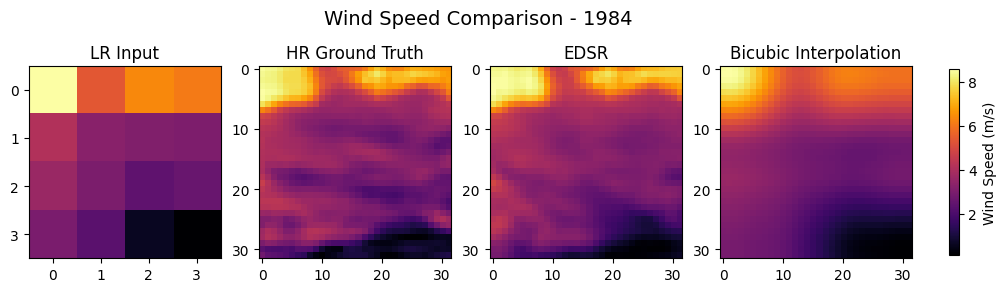

In [154]:
def plot_comparison(fields, names, index):
    assert len(fields) == len(names)
    fig, ax = plt.subplots(1, len(names), figsize=(12, 6))
    fields = [field[index] for field in fields]
    for i, field in enumerate(fields):
        if names[i] == "HR Ground Truth":
            im = ax[i].imshow(field, cmap='inferno')
        else:
            ax[i].imshow(field, cmap='inferno')
        ax[i].set_title(names[i])
        #ax[i].axis('off')
    cbar = fig.colorbar(im, ax=ax, orientation='vertical', fraction=0.01, pad=0.04)
    cbar.set_label('Wind Speed (m/s)')
    plt.suptitle(f"Wind Speed Comparison - {TEST_YEAR}", fontsize=14, y=.75)
    plt.show()

ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                        scaling_factor=SCALING_FACTOR, 
                                        year=TEST_YEAR, 
                                        normalization_scale=scale, 
                                        lr_ws=lr_wind_speeds, 
                                        gt_ws=ground_truth_wind_speeds)

index = np.random.randint(0, len(ground_truth_wind_speeds))
print(index)
plot_comparison(ws_fields, names, index)




In [155]:
print(np.mean(ground_truth_wind_speeds))
print(np.std(ground_truth_wind_speeds))
print(np.min(ground_truth_wind_speeds))
print(np.max(ground_truth_wind_speeds))

3.7423608
2.4426157
0.0011898181
23.356188


In [156]:
# Metrics in original range
edsr, baseline = ws_fields[names.index("EDSR")], ws_fields[names.index("Bicubic Interpolation")]
mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds)
mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds)
print(f"EDSR: MSE: {mse_edsr:.4f}, MAE: {mae_edsr:.4f}")
print(f"Baseline: MSE: {mse_baseline:.4f}, MAE: {mae_baseline:.4f}")


EDSR: MSE: 0.2327, MAE: 0.3413
Baseline: MSE: 0.6625, MAE: 0.5828


# Compare Metrics over years

In [157]:
def get_metrics_over_time(years):
    mses = {'EDSR': [], 'Bicubic': []}
    maes = {'EDSR': [], 'Bicubic': []}
    mse_skill_scores = []
    mae_skill_scores = []
    for year in years:
        eval_split, ground_truth_wind_speeds, scale = get_ground_truth_ws(data_dir=dataset_dir,
                                                                        train_start=TRAIN_START,
                                                                        train_end=TRAIN_END,
                                                                        test_year=year)
        
        lr_wind_speeds = get_low_res_ws(eval_split, SCALING_FACTOR)
        ws_fields, names = get_wind_speed_fields(files_dir=preds_dir, 
                                                scaling_factor=SCALING_FACTOR, 
                                                year=year, 
                                                normalization_scale=scale, 
                                                lr_ws=lr_wind_speeds, 
                                                gt_ws=ground_truth_wind_speeds)
        edsr = ws_fields[names.index('EDSR')]
        baseline = ws_fields[names.index('Bicubic Interpolation')]
        
        mse_edsr, mae_edsr = get_metrics(edsr, ground_truth_wind_speeds)
        mse_baseline, mae_baseline = get_metrics(baseline, ground_truth_wind_speeds)
        mse_skill_scores.append(get_skill_score(mse_edsr, mse_baseline))
        mae_skill_scores.append(get_skill_score(mae_edsr, mae_baseline))
        
        mses['EDSR'].append(mse_edsr)
        mses['Bicubic'].append(mse_baseline)
        maes['EDSR'].append(mae_edsr)
        maes['Bicubic'].append(mae_baseline)
        
        print(f"Year: {year}")
        print(f"EDSR: MSE: {mse_edsr:.4f}, MAE: {mae_edsr:.4f}")
        print(f"Bicubic: MSE: {mse_baseline:.4f}, MAE: {mae_baseline:.4f}")
        print(f"Skill Score (MSE): {get_skill_score(mse_edsr, mse_baseline):.4f}, (MAE): {get_skill_score(mae_edsr, mae_baseline):.4f} ")
    return mses, maes, mse_skill_scores, mae_skill_scores



def plot_metrics_over_time(years, mses, maes):
    n_models = len(mses)
    fig, ax = plt.subplots(n_models, 2, figsize=(12, 4 * n_models))
    
    for i, model in enumerate(mses):
        # Plot MSE for the current model
        ax[i, 0].plot(years, mses[model], 'o-', label=f"{model} - MSE", color='blue')
        ax[i, 0].set_title(f'{model} - MSE')
        ax[i, 0].set_xlabel('Year')
        ax[i, 0].set_ylabel('MSE')
        ax[i, 0].legend()
        ax[i, 0].grid(True)

        # Plot MAE for the current model
        ax[i, 1].plot(years, maes[model], 'o-', label=f"{model} - MAE", color='orange')
        ax[i, 1].set_title(f'{model} - MAE')
        ax[i, 1].set_xlabel('Year')
        ax[i, 1].set_ylabel('MAE')
        ax[i, 1].legend()
        ax[i, 1].grid(True)

    plt.tight_layout()
    plt.show()
    
def plot_skill_scores(years, mse_ss, mae_ss):
    fig, ax = plt.subplots(1, 2, figsize=(10, 5))
    ax[0].plot(years, mse_ss, 'o-', label='MSE Skill Score', color='blue')
    ax[0].set_title('MSE Skill Score')
    ax[0].set_xlabel('Year')
    ax[0].set_ylabel('Skill Score')
    ax[0].legend()
    ax[0].grid(True)

    ax[1].plot(years, mae_ss, 'o-', label='MAE Skill Score', color='orange')
    ax[1].set_title('MAE Skill Score')
    ax[1].set_xlabel('Year')
    ax[1].set_ylabel('Skill Score')
    ax[1].legend()
    ax[1].grid(True)

    plt.tight_layout()
    plt.show()
    

In [158]:
years = [1984 + 5*i for i in range(8)]
years.append(2023)
mses, maes, mse_skill_scores, mae_skill_scores = get_metrics_over_time(years)

Year: 1984
EDSR: MSE: 0.2327, MAE: 0.3413
Bicubic: MSE: 0.6625, MAE: 0.5828
Skill Score (MSE): 0.6488, (MAE): 0.4143 
Year: 1989
EDSR: MSE: 0.2256, MAE: 0.3380
Bicubic: MSE: 0.6590, MAE: 0.5833
Skill Score (MSE): 0.6576, (MAE): 0.4205 
Year: 1994
EDSR: MSE: 0.2303, MAE: 0.3439
Bicubic: MSE: 0.6963, MAE: 0.6019
Skill Score (MSE): 0.6693, (MAE): 0.4286 
Year: 1999
EDSR: MSE: 0.2276, MAE: 0.3428
Bicubic: MSE: 0.6730, MAE: 0.5894
Skill Score (MSE): 0.6619, (MAE): 0.4184 
Year: 2004
EDSR: MSE: 0.2332, MAE: 0.3499
Bicubic: MSE: 0.6657, MAE: 0.5894
Skill Score (MSE): 0.6496, (MAE): 0.4064 
Year: 2009
EDSR: MSE: 0.2392, MAE: 0.3516
Bicubic: MSE: 0.6693, MAE: 0.5879
Skill Score (MSE): 0.6426, (MAE): 0.4020 
Year: 2014
EDSR: MSE: 0.2289, MAE: 0.3479
Bicubic: MSE: 0.6561, MAE: 0.5895
Skill Score (MSE): 0.6511, (MAE): 0.4097 
Year: 2019
EDSR: MSE: 0.2444, MAE: 0.3556
Bicubic: MSE: 0.6769, MAE: 0.5974
Skill Score (MSE): 0.6390, (MAE): 0.4047 
Year: 2023
EDSR: MSE: 0.2638, MAE: 0.3679
Bicubic: MSE: 

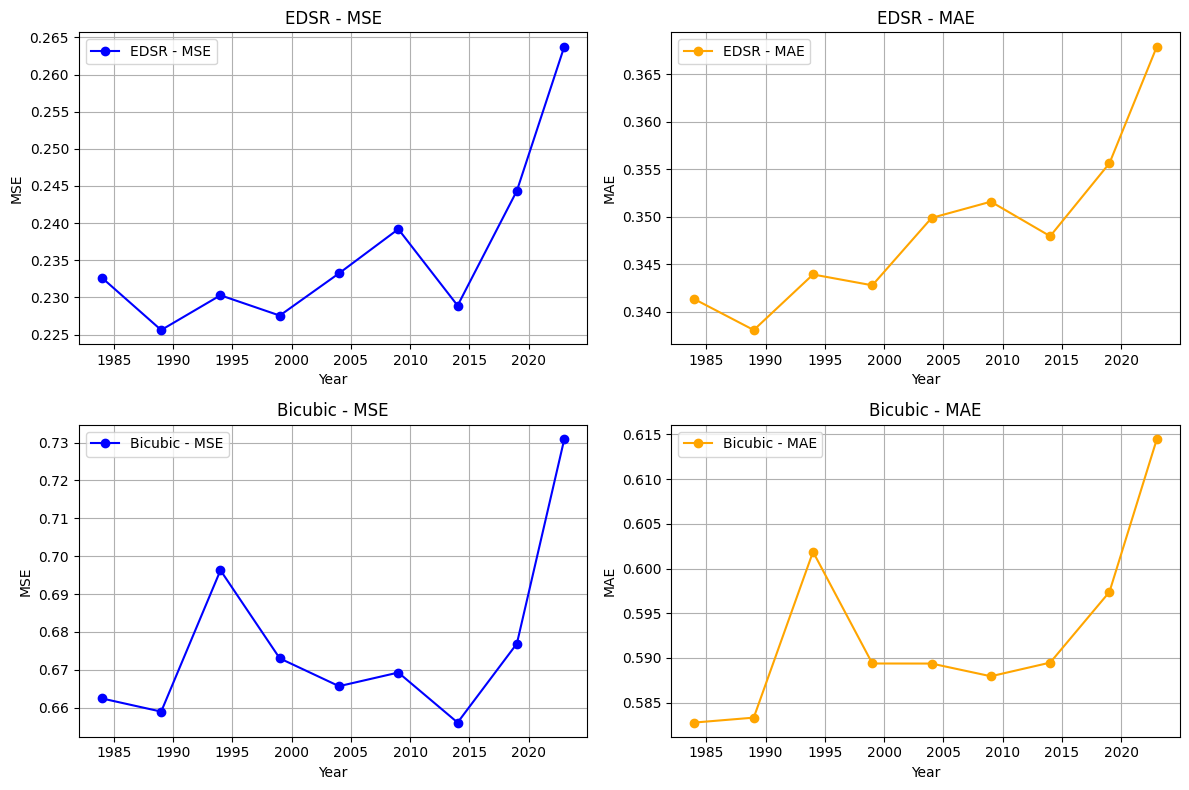

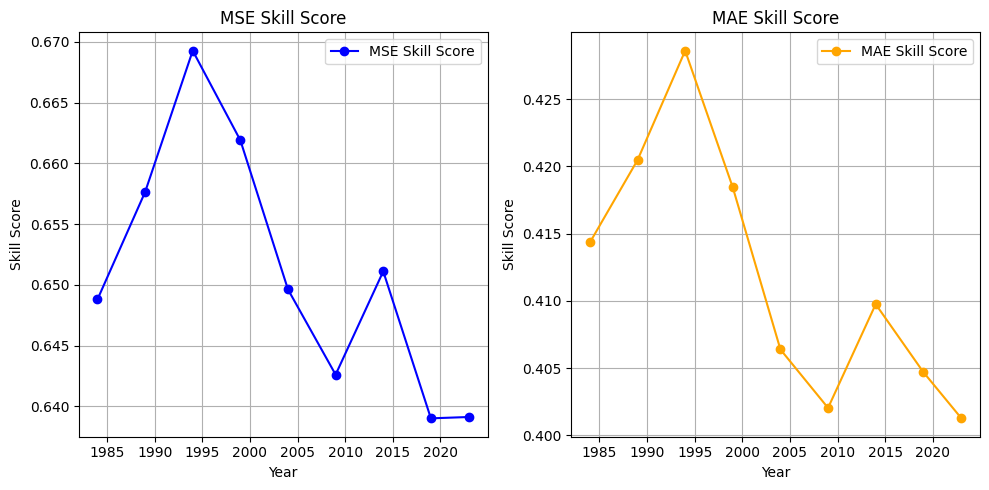

In [159]:
plot_metrics_over_time(years, mses, maes)
plot_skill_scores(years, mse_skill_scores, mae_skill_scores)

In [160]:
def get_stats_over_time(years):
    gt_statistics = {'mean': [], 'var': [], 'std' :[]}

    for year in years:
        _, gt_ws, _ = get_ground_truth_ws(data_dir=dataset_dir,
                                            train_start=TRAIN_START,
                                            train_end=TRAIN_END,
                                            test_year=year)
        gt_statistics['mean'].append(gt_ws.mean())
        gt_statistics['var'].append(gt_ws.var())
        gt_statistics['std'].append(gt_ws.std())
        
    return gt_statistics

gt_stats = get_stats_over_time(years)


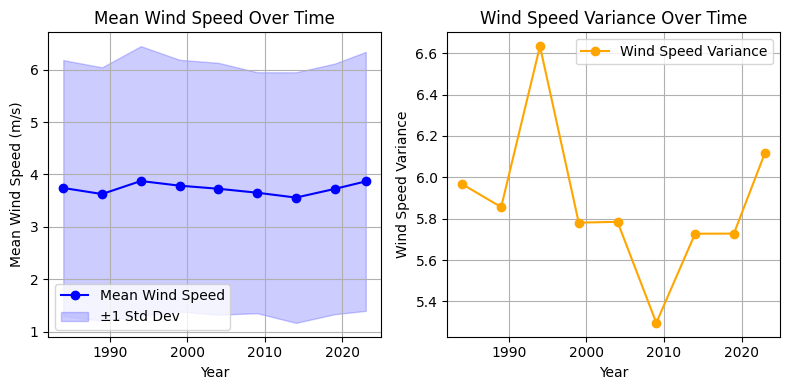

In [161]:
fig, ax = plt.subplots(1, 2, figsize=(8, 4))

# Plot Mean Wind Speed with Standard Deviation Range
gt_stats['mean'] = np.array(gt_stats['mean'])
gt_stats['var'] = np.array(gt_stats['var'])
gt_stats['std'] = np.array(gt_stats['std'])
ax[0].plot(years, gt_stats['mean'], 'o-', label='Mean Wind Speed', color='blue')

ax[0].fill_between(
    years,
    gt_stats['mean'] - gt_stats['std'],  
    gt_stats['mean'] + gt_stats['std'], 
    color='blue',
    alpha=0.2,
    label='±1 Std Dev'
)

ax[0].set_title('Mean Wind Speed Over Time')
ax[0].set_xlabel('Year')
ax[0].set_ylabel('Mean Wind Speed (m/s)')
ax[0].legend()
ax[0].grid(True)

# Plot Wind Speed Variance Over Time
ax[1].plot(years, gt_stats['var'], 'o-', label='Wind Speed Variance', color='orange')
ax[1].set_title('Wind Speed Variance Over Time')
ax[1].set_xlabel('Year')
ax[1].set_ylabel('Wind Speed Variance')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


In [162]:
from scipy.stats import pearsonr
mse_corr, p_mse = pearsonr(gt_stats['mean'], mses['EDSR'])
mae_corr, p_mae = pearsonr(gt_stats['mean'], maes['EDSR'])
mse_corr_baseline, p_mse_baseline = pearsonr(gt_stats['mean'], mses['Bicubic'])
mae_corr_baseline, p_mae_baseline= pearsonr(gt_stats['mean'], maes['Bicubic'])

print(f"Correlation between Mean Wind Speed and EDSR MSE: {mse_corr:.4f} with p-value: {p_mse:.4f}")
print(f"Correlation between Mean Wind Speed and EDSR MAE: {mae_corr:.4f} with p-value: {p_mae:.4f}")
print(f"Correlation between Mean Wind Speed and Bicubic MSE: {mse_corr_baseline:.4f} with p-value: {p_mse_baseline:.4f}")
print(f"Correlation between Mean Wind Speed and Bicubic MAE: {mae_corr_baseline:.4f} with p-value: {p_mae_baseline:.4f}")


Correlation between Mean Wind Speed and EDSR MSE: 0.4458 with p-value: 0.2291
Correlation between Mean Wind Speed and EDSR MAE: 0.3263 with p-value: 0.3915
Correlation between Mean Wind Speed and Bicubic MSE: 0.7964 with p-value: 0.0102
Correlation between Mean Wind Speed and Bicubic MAE: 0.6883 with p-value: 0.0404


In [163]:
mse_corr, p_mse = pearsonr(gt_stats['var'], mses['EDSR'])
mae_corr, p_mae = pearsonr(gt_stats['var'], maes['EDSR'])
mse_corr_baseline, p_mse_baseline = pearsonr(gt_stats['var'], mses['Bicubic'])
mae_corr_baseline, p_mae_baseline= pearsonr(gt_stats['var'], maes['Bicubic'])

print(f"Correlation between Wind Speed Variance and EDSR MSE: {mse_corr:.4f} with p-value: {p_mse:.4f}")
print(f"Correlation between Wind Speed Variance and EDSR MAE: {mae_corr:.4f} with p-value: {p_mae:.4f}")
print(f"Correlation between Wind Speed Variance and Bicubic MSE: {mse_corr_baseline:.4f} with p-value: {p_mse_baseline:.4f}")
print(f"Correlation between Wind Speed Variance and Bicubic MAE: {mae_corr_baseline:.4f} with p-value: {p_mae_baseline:.4f}")

Correlation between Wind Speed Variance and EDSR MSE: 0.0375 with p-value: 0.9238
Correlation between Wind Speed Variance and EDSR MAE: -0.0606 with p-value: 0.8768
Correlation between Wind Speed Variance and Bicubic MSE: 0.5241 with p-value: 0.1475
Correlation between Wind Speed Variance and Bicubic MAE: 0.5013 with p-value: 0.1692


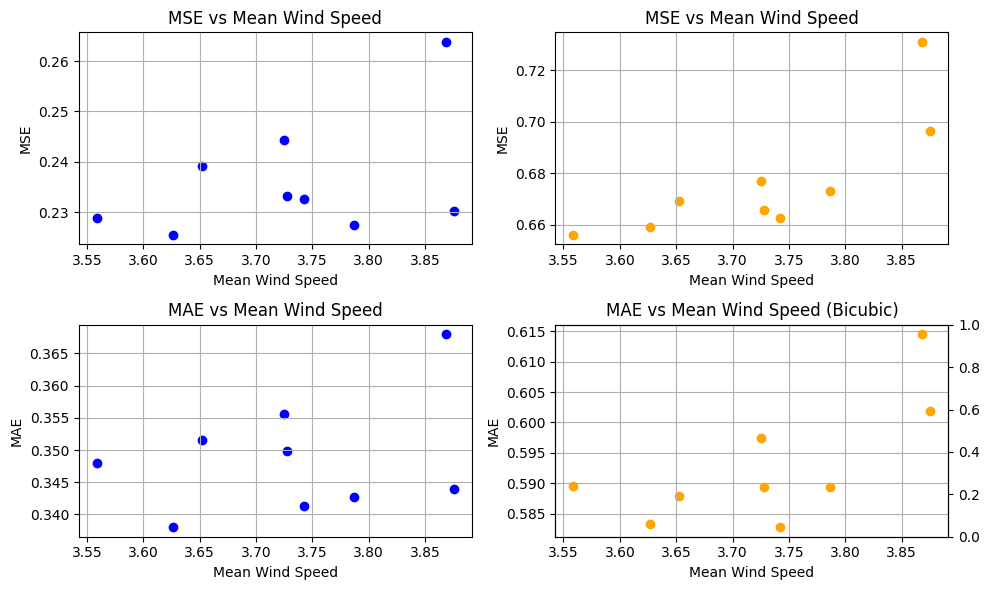

In [164]:
# plot correlation between error and mean wind speed
fig, ax = plt.subplots(2, 2, figsize=(10, 6))
ax[0, 0].scatter(gt_stats['mean'], mses['EDSR'], color='blue')
ax[0, 0].set_title('MSE vs Mean Wind Speed')
ax[0, 0].set_xlabel('Mean Wind Speed')
ax[0, 0].set_ylabel('MSE')
ax[0, 0].grid(True)

ax[0, 1].scatter(gt_stats['mean'], mses['Bicubic'], color='orange')
ax[0, 1].set_title('MSE vs Mean Wind Speed')
ax[0, 1].set_xlabel('Mean Wind Speed')
ax[0, 1].set_ylabel('MSE')
ax[0, 1].grid(True)

ax[1,0].scatter(gt_stats['mean'], maes['EDSR'], color='blue')
ax[1,0].set_title('MAE vs Mean Wind Speed')
ax[1,0].set_xlabel('Mean Wind Speed')
ax[1,0].set_ylabel('MAE')
ax[1,0].grid(True)

ax[1,1].scatter(gt_stats['mean'], maes['Bicubic'], color='orange')
ax[1,1].set_title('MAE vs Mean Wind Speed')
ax[1, 1].set_title('MAE vs Mean Wind Speed (Bicubic)')

ax2 = ax[1, 1].twinx()
ax[1,1].set_xlabel('Mean Wind Speed')
ax[1,1].set_ylabel('MAE')
ax[1,1].grid(True)


plt.tight_layout()
plt.show()

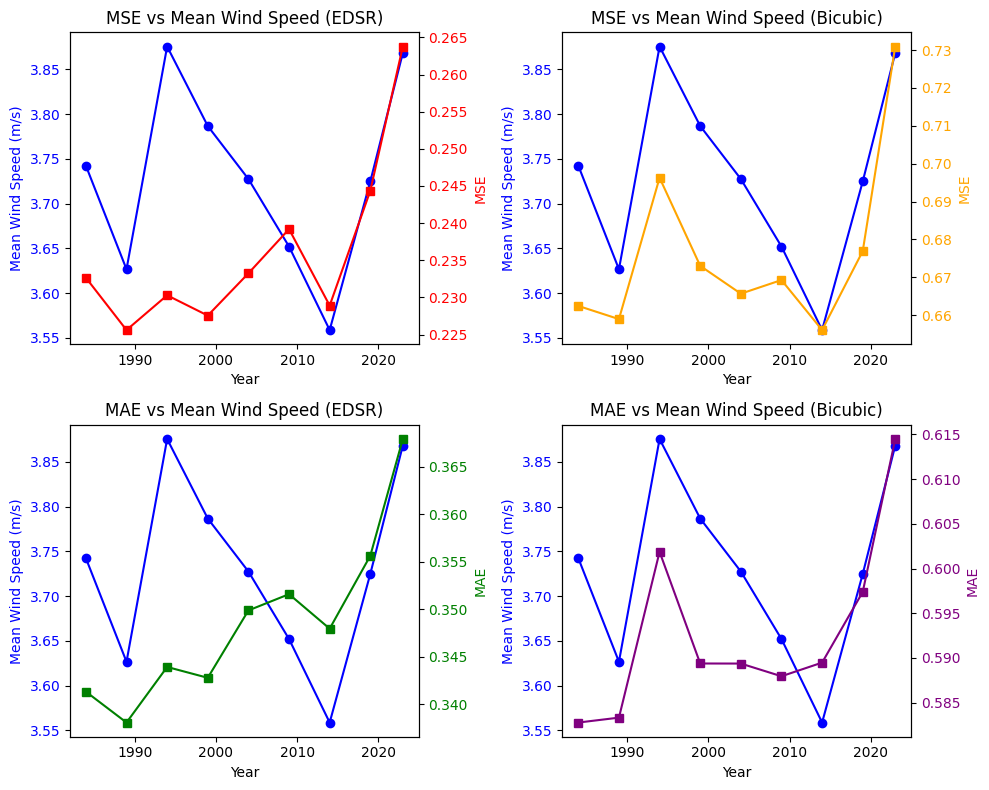

In [165]:
fig, ax = plt.subplots(2, 2, figsize=(10, 8))

# MSE vs Mean Wind Speed (EDSR)
ax[0, 0].plot(years, gt_stats['mean'], 'o-', color='blue', label='Mean Wind Speed')
ax[0, 0].set_xlabel('Year')
ax[0, 0].set_ylabel('Mean Wind Speed (m/s)', color='blue')
ax[0, 0].tick_params(axis='y', labelcolor='blue')
ax[0, 0].set_title('MSE vs Mean Wind Speed (EDSR)')

ax2 = ax[0, 0].twinx()
ax2.plot(years, mses['EDSR'], 's-', color='red', label='MSE (EDSR)')
ax2.set_ylabel('MSE', color='red')
ax2.tick_params(axis='y', labelcolor='red')
ax2.grid(False)  # Disables grid on right axis to avoid clutter

# MSE vs Mean Wind Speed (Bicubic)
ax[0, 1].plot(years, gt_stats['mean'], 'o-', color='blue', label='Mean Wind Speed')
ax[0, 1].set_xlabel('Year')
ax[0, 1].set_ylabel('Mean Wind Speed (m/s)', color='blue')
ax[0, 1].tick_params(axis='y', labelcolor='blue')
ax[0, 1].set_title('MSE vs Mean Wind Speed (Bicubic)')

ax2 = ax[0, 1].twinx()
ax2.plot(years, mses['Bicubic'], 's-', color='orange', label='MSE (Bicubic)')
ax2.set_ylabel('MSE', color='orange')
ax2.tick_params(axis='y', labelcolor='orange')
ax2.grid(False)

# MAE vs Mean Wind Speed (EDSR)
ax[1, 0].plot(years, gt_stats['mean'], 'o-', color='blue', label='Mean Wind Speed')
ax[1, 0].set_xlabel('Year')
ax[1, 0].set_ylabel('Mean Wind Speed (m/s)', color='blue')
ax[1, 0].tick_params(axis='y', labelcolor='blue')
ax[1, 0].set_title('MAE vs Mean Wind Speed (EDSR)')

ax2 = ax[1, 0].twinx()
ax2.plot(years, maes['EDSR'], 's-', color='green', label='MAE (EDSR)')
ax2.set_ylabel('MAE', color='green')
ax2.tick_params(axis='y', labelcolor='green')
ax2.grid(False)

# MAE vs Mean Wind Speed (Bicubic)
ax[1, 1].plot(years, gt_stats['mean'], 'o-', color='blue', label='Mean Wind Speed')
ax[1, 1].set_xlabel('Year')
ax[1, 1].set_ylabel('Mean Wind Speed (m/s)', color='blue')
ax[1, 1].tick_params(axis='y', labelcolor='blue')
ax[1, 1].set_title('MAE vs Mean Wind Speed (Bicubic)')

ax2 = ax[1, 1].twinx()
ax2.plot(years, maes['Bicubic'], 's-', color='purple', label='MAE (Bicubic)')
ax2.set_ylabel('MAE', color='purple')
ax2.tick_params(axis='y', labelcolor='purple')
ax2.grid(False)

plt.tight_layout()
plt.show()


# Regression on model error over time

## Linear regression

### MSE

In [166]:
from sklearn.linear_model import LinearRegression

Linear Regression Coefficient: 0.0006, Intercept: -1.0263
R² Score: 0.5121


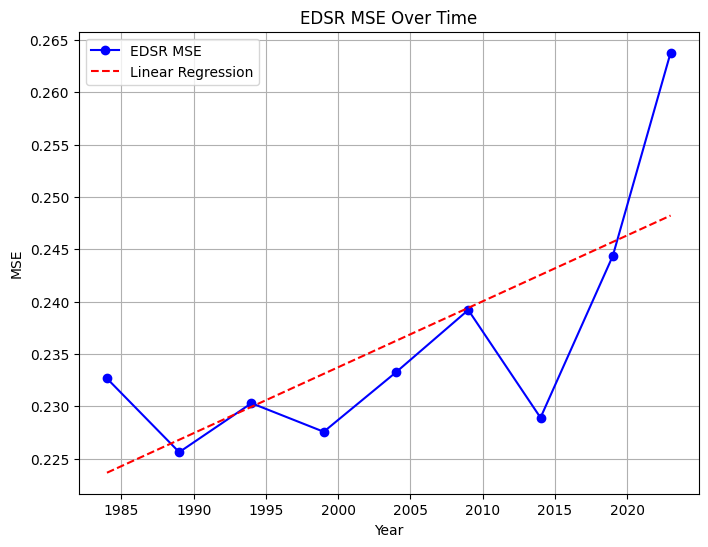

In [167]:
X = np.array(years).reshape(-1, 1)
y = np.array(mses['EDSR']).reshape(-1, 1)
reg = LinearRegression().fit(X, y)
print(f"Linear Regression Coefficient: {reg.coef_[0][0]:.4f}, Intercept: {reg.intercept_[0]:.4f}")
print(f"R² Score: {reg.score(X, y):.4f}")
#plot linear regression
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(years, mses['EDSR'], 'o-', label='EDSR MSE', color='blue')
ax.plot(years, reg.predict(X), '--', label='Linear Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()

### MAE

Linear Regression Coefficient: 0.0006, Intercept: -0.8328
R² Score: 0.7764


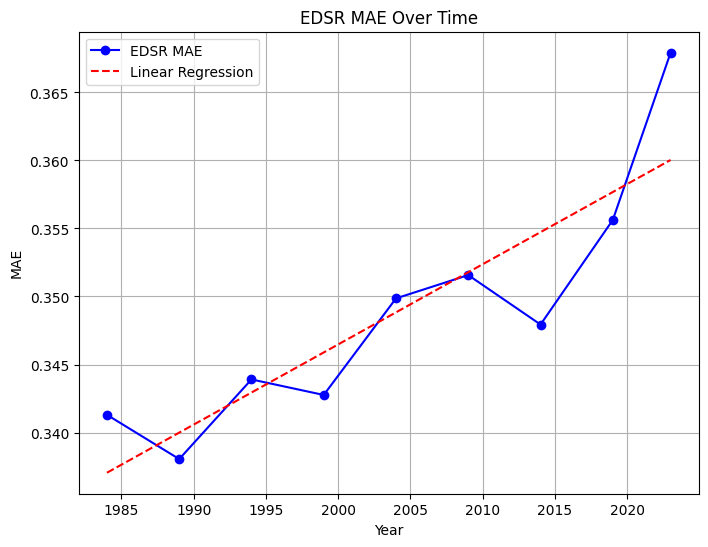

In [168]:
y = np.array(maes['EDSR']).reshape(-1, 1)
reg = LinearRegression().fit(X, y)
print(f"Linear Regression Coefficient: {reg.coef_[0][0]:.4f}, Intercept: {reg.intercept_[0]:.4f}")
print(f"R² Score: {reg.score(X, y):.4f}")
#plot linear regression
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(years, maes['EDSR'], 'o-', label='EDSR MAE', color='blue')
ax.plot(years, reg.predict(X), '--', label='Linear Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()

## Exp Regression


### MSE

Exponential Regression Coefficients: [ 1.66271248e-04 -6.63712367e-01  6.60860643e+02]
R² Score for Exponential Regression: 0.7802


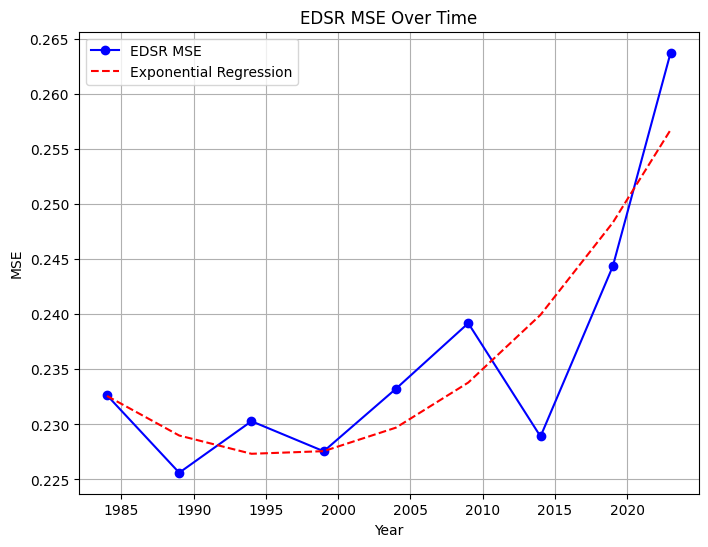

Predicted MSE for 2024: 0.2591


In [ ]:
mses['EDSR'] = np.array(mses['EDSR'])
fit = np.polyfit(years, np.log(mses['EDSR']), 2)
print(f"Exponential Regression Coefficients: {fit}")
predicted_mse = np.exp(np.polyval(fit, years))
# get residual error
r_squared = 1 - (np.sum((predicted_mse - mses['EDSR'])**2) / np.sum((mses['EDSR'] - mses['EDSR'].mean())**2))

print(f"R² Score for Exponential Regression: {r_squared:.4f}")
fig, ax = plt.subplots(1, 1, figsize=(8, 6))
ax.plot(years, mses['EDSR'], 'o-', label='EDSR MSE', color='blue')
ax.plot(years, np.exp(np.polyval(fit, years)), '--', label='Exponential Regression', color='red')
ax.set_title('EDSR MSE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MSE')
ax.legend()
ax.grid(True)
plt.show()

#now predict for 2024
predicted_mse_2024 = np.exp(np.polyval(fit, [2024]))
print(f"Predicted MSE for 2024: {predicted_mse_2024[0]:.4f}")



### MAE

Exponential Regression Coefficients: [ 4.67860736e-05 -1.85808511e-01  1.83405594e+02]
R² Score for Exponential Regression: 0.8559


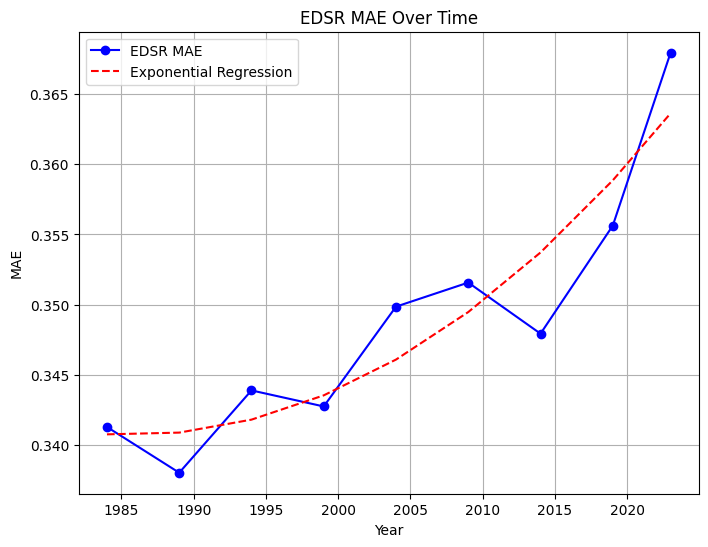

In [170]:
maes['EDSR'] = np.array(maes['EDSR'])
fit = np.polyfit(years, np.log(maes['EDSR']), 2)
print(f"Exponential Regression Coefficients: {fit}")
predicted_mae = np.exp(np.polyval(fit, years))

ss_res = np.sum((maes['EDSR'] - predicted_mae) ** 2)
ss_tot = np.sum((maes['EDSR'] - np.mean(maes['EDSR'])) ** 2)
r_squared = 1 - (ss_res / ss_tot)
print(f"R² Score for Exponential Regression: {r_squared:.4f}")

fig, ax = plt.subplots(1, 1, figsize=(8, 6))    
ax.plot(years, maes['EDSR'], 'o-', label='EDSR MAE', color='blue')
ax.plot(years, np.exp(np.polyval(fit, years)), '--', label='Exponential Regression', color='red')
ax.set_title('EDSR MAE Over Time')
ax.set_xlabel('Year')
ax.set_ylabel('MAE')
ax.legend()
ax.grid(True)
plt.show()

